<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">


# Clustering and K-Means Lab


---


### Lab Objectives
* Penguin dataset is used mainly for classification as we have labels, however, we will assume we do not have a label and we would use the dataset for clustering 


In [46]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')
# %matplotlib inline

#### Describing the data

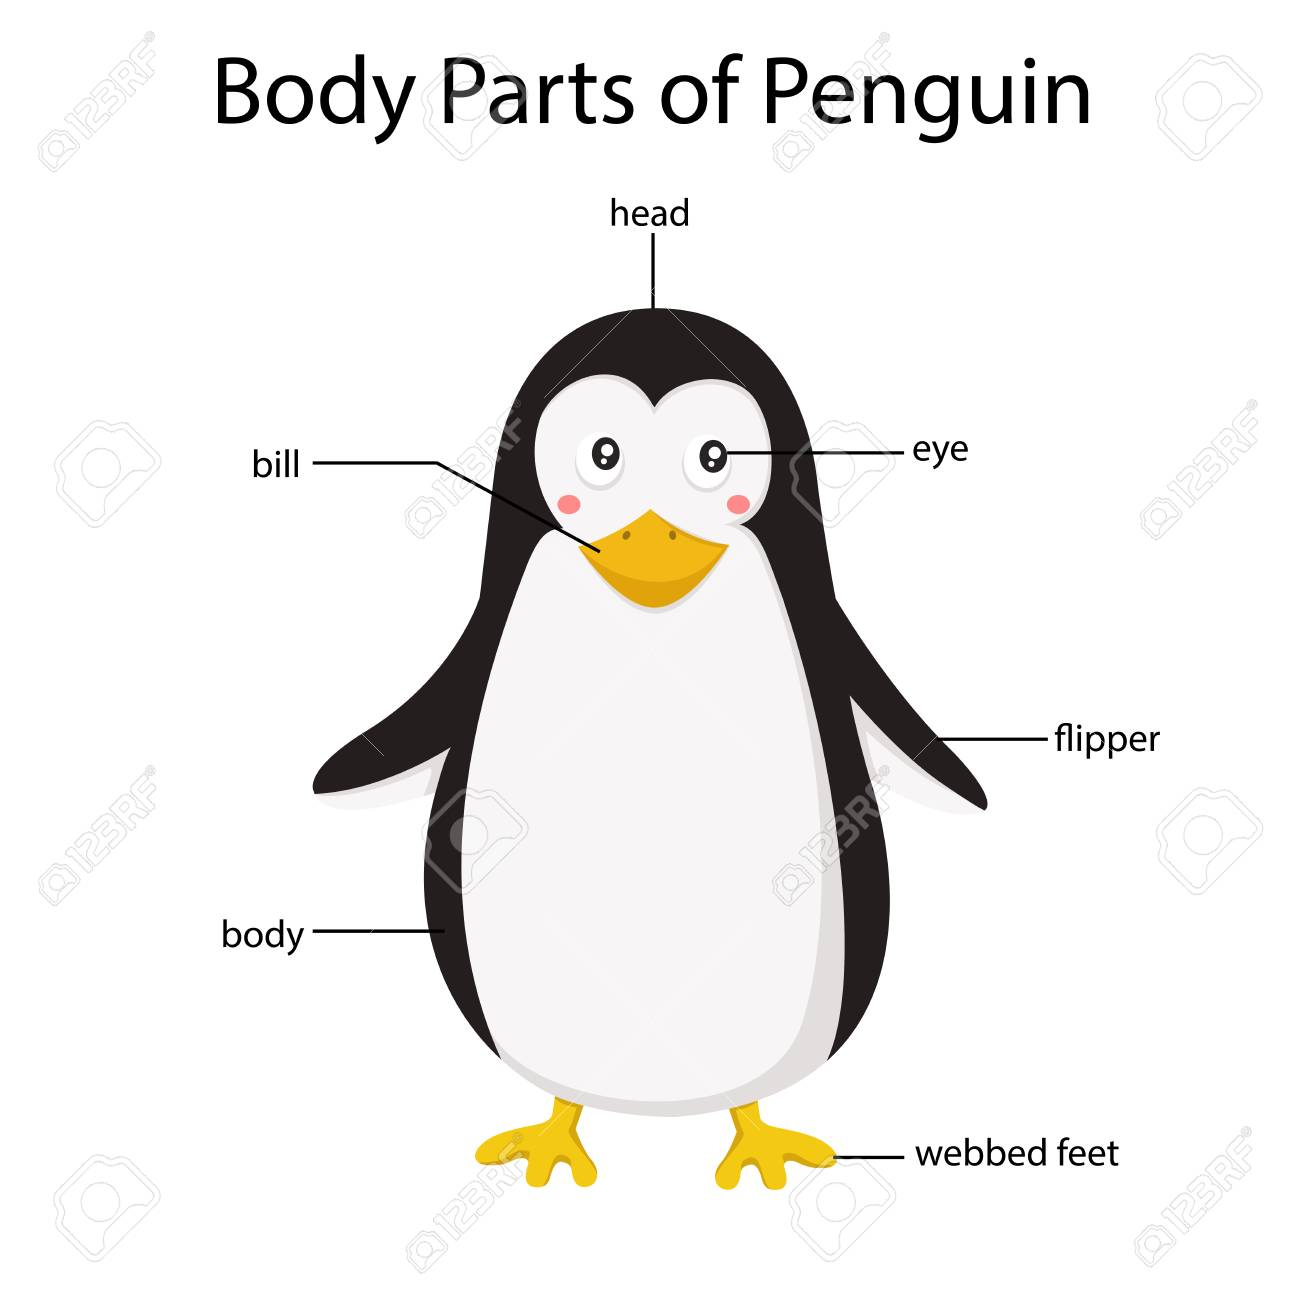

**Columns in the dataset** 
- Species: penguin species (Chinstrap, Adélie, or Gentoo)
- Island: island name (Dream, Torgersen, or Biscoe) in the Palmer Archipelago (Antarctica)
- flipper_length_mm: flipper length (mm)
- body_mass_g: body mass (g)
- Sex: penguin sex



In [71]:
# load the dataset from seaborn using sns.load_dataset. It is called penguins
penguins = sns.load_dataset('penguins')

# show the head
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [72]:
# check columns info
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [73]:
# do we have any nulls?
penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [74]:
# Drop null values from the dataset
penguins.dropna(inplace=True)
# check the shape after dropping
penguins.shape


(333, 7)

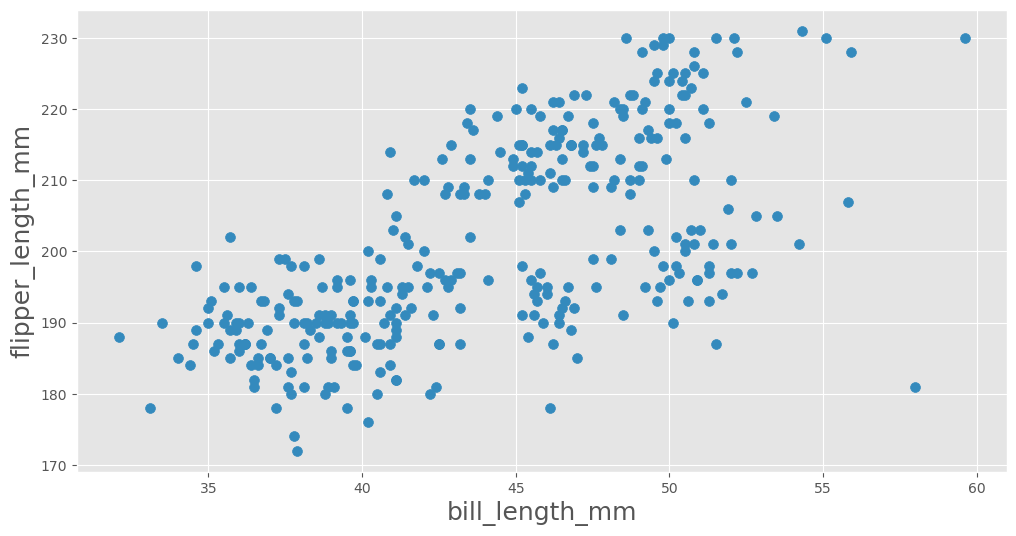

In [75]:
# make scatter between bill length and flipper length
penguins.plot(kind="scatter", x="bill_length_mm", y="flipper_length_mm", figsize=(12,6), s=50)
plt.xlabel("bill_length_mm", fontsize=18)
plt.ylabel("flipper_length_mm", fontsize=18);

In [76]:
# No code here



In [77]:
# set our X features to be bill length and flipper length

X = penguins[['bill_length_mm', 'flipper_length_mm']]

In [78]:
# Important step: scale the data
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [96]:
# instantiate kmeans model with 8 cluster, random state 7
model1 = KMeans(n_clusters=8, random_state=7)
model1.fit(X_scaled)

KMeans(random_state=7)

In [97]:
# get centroids of model1
# inverse the scaling of cluster_centers_ and save it into a variable centers
centers = sc.inverse_transform(km.cluster_centers_)

# create a dataframe called cluster1 contains the centers, define the column names as x1 and y1
cluster1 = pd.DataFrame(centers, columns=['x1', 'y1'])
cluster1



,x1,y1
0,39.302703,182.594595
1,46.322414,214.086207
2,36.991781,190.575342
3,50.959524,198.428571
4,43.692157,192.549020
5,49.780488,222.097561
6,54.385714,229.571429
7,42.416667,207.083333


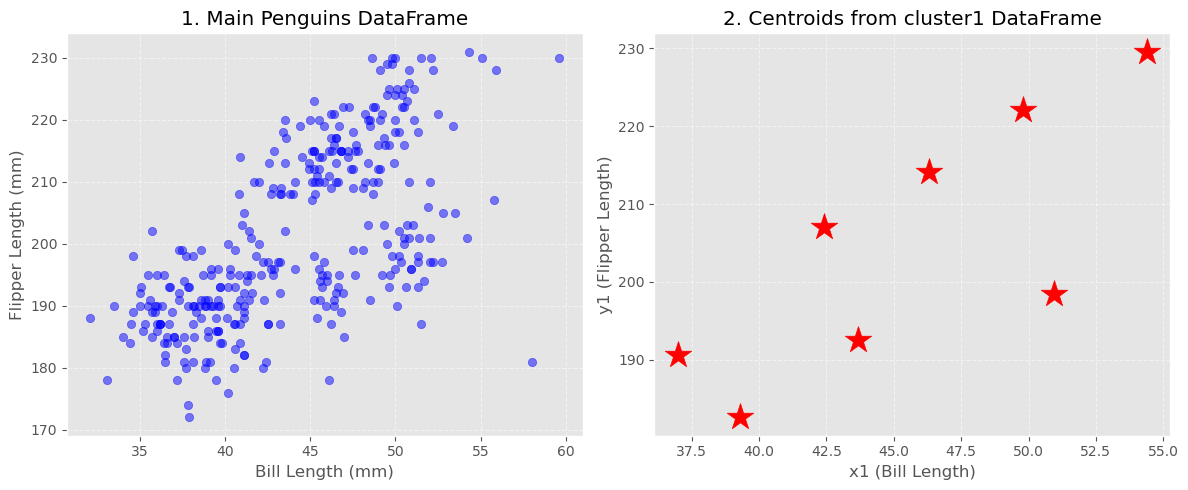

In [100]:
# create two scatter plots:
# first:  from penguins main dataframe,plotting bill length against flipper length
# second: from clusters dataframe that you have created in previous code cell
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(penguins['bill_length_mm'], penguins['flipper_length_mm'], c='blue', alpha=0.5)
plt.title('1. Main Penguins DataFrame')
plt.xlabel('Bill Length (mm)')
plt.ylabel('Flipper Length (mm)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.scatter(cluster1['x1'], cluster1['y1'], marker='*', c='red', s=400)
plt.title('2. Centroids from cluster1 DataFrame')
plt.xlabel('x1 (Bill Length)')
plt.ylabel('y1 (Flipper Length)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [90]:
# instantiate kmeans model with 3 cluster, random state 7
model2 = KMeans(n_clusters=3, random_state=7)

# fit the model
model2.fit(X_scaled)
# what are the models cluster centers?
model2.cluster_centers_


array([[-0.96427851, -0.80518575],
       [ 0.66403058,  1.15087842],
       [ 0.9235766 , -0.37501448]])

In [102]:
# get centroids of model2
# inverse the scaling of cluster_centers_ and save it into a variable centers2
centers2 = sc.inverse_transform(km.cluster_centers_)


# create a dataframe called cluster2 contains the centers2, 
# define the column names as x1 and y1
cluster2 = pd.DataFrame(centers, columns=['x1', 'y1'])
cluster2


,x1,y1
0,39.302703,182.594595
1,46.322414,214.086207
2,36.991781,190.575342
3,50.959524,198.428571
4,43.692157,192.549020
5,49.780488,222.097561
6,54.385714,229.571429
7,42.416667,207.083333


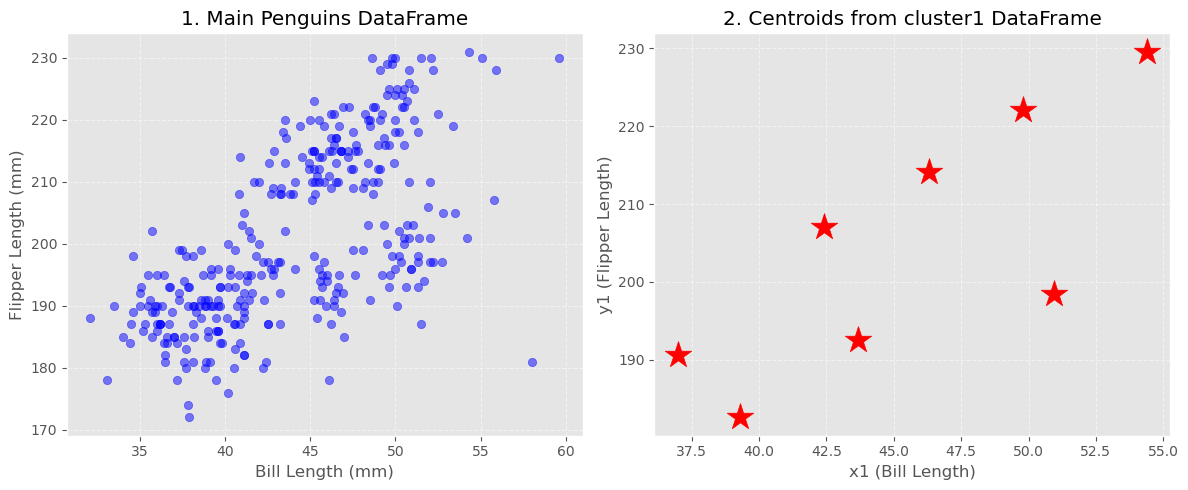

In [103]:
# create two scatter plots:
# first:  from penguins main dataframe,plotting bill length against flipper length
# second: from clusters dataframe that you have created in previous code cell

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(penguins['bill_length_mm'], penguins['flipper_length_mm'], c='blue', alpha=0.5)
plt.title('1. Main Penguins DataFrame')
plt.xlabel('Bill Length (mm)')
plt.ylabel('Flipper Length (mm)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.scatter(cluster2['x1'], cluster2['y1'], marker='*', c='red', s=400)
plt.title('2. Centroids from cluster1 DataFrame')
plt.xlabel('x1 (Bill Length)')
plt.ylabel('y1 (Flipper Length)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [105]:
# create a column cluster_labels in penguins dataframe that has the predictions
penguins['cluster_labels'] = model2.predict(X_scaled)

# display the penguins dataframe with the species and cluster_labels columns
penguins[['species', 'cluster_labels']]



,species,cluster_labels
0,Adelie,0
1,Adelie,0
2,Adelie,0
4,Adelie,0
5,Adelie,0
...,...,...
338,Gentoo,1
340,Gentoo,1
341,Gentoo,1
342,Gentoo,1


> Let's see if the model matches the correct cluster groups or not

In [106]:
# make a crosstab in penguins dataframe between species and cluster_labels
pd.crosstab(penguins['species'], penguins['cluster_labels'])



cluster_labels,0,1,2
species,,,
Adelie,141,1,4
Chinstrap,5,4,59
Gentoo,0,118,1
